In [452]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox, ttk

In [453]:
iris = pd.read_csv('Iris.csv')

In [454]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [455]:
iris = iris.drop('Id', axis=1)

In [456]:
iris['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [457]:
iris['Species'] = iris['Species'].map({'Iris-setosa':0,
                                       'Iris-versicolor':1,
                                       'Iris-virginica':2})

In [458]:
iris.duplicated().sum()

np.int64(3)

In [459]:
iris['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [460]:
feature = iris.select_dtypes(include='number')

# normalisasi
data_scaled = (feature - feature.min(axis=0)) / (feature.max(axis=0) - feature.min(axis=0))

# standarisasi
# data_scaled = (feature - feature.mean(axis=0)) / (feature.std(axis=0) + 1e-9)

In [461]:
def kmean(data, k, p=2, iteration=200):
    np.random.seed(42)
    X = data.values
    random_idx = np.random.choice(len(X), k, replace=False)
    centroid = X[random_idx]

    for i in range(iteration):
        diff = np.abs(X[:, np.newaxis] - centroid)

        distance = np.sum(diff**p, axis=2)**(1/p)

        label = np.argmin(distance, axis=1)

        new_centroid = np.array([X[label == i].mean(axis=0) for i in range(k)])
        if np.linalg.norm(new_centroid - centroid) < 1e-4:
            break
        centroid = new_centroid
    return label, centroid

In [462]:
def wcss(data, k, p=2):
    cluster, centroid = kmean(data_scaled, k, p=2)
    X = data.values

    diff = np.abs(X[:, np.newaxis] - centroid)
    distance = np.sum(diff**p, axis=1)**(1/p)
    min_distance = np.argmin(distance, axis=1)

    if p == 2:
        error = np.sum(min_distance ** 2)
    else:
        error = np.sum(min_distance)
    return error


In [463]:
hasil_wcss = wcss(data_scaled, k)
hasil_wcss

np.int64(122)

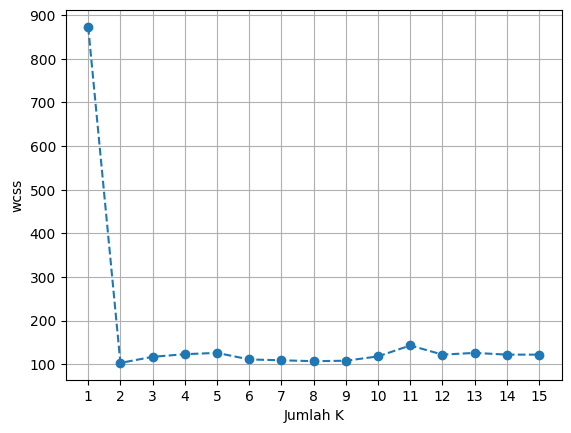

In [464]:
def elbow(data, range_k=range(1,16)):
    wcss_value = []

    for k in range_k:
        hasil_wcss = wcss(data, k)
        wcss_value.append(hasil_wcss)
    plt.plot(range_k, wcss_value, marker='o', linestyle='--')
    plt.xticks((range_k))
    plt.ylabel('wcss')
    plt.xlabel('Jumlah K')
    plt.grid(True)
    plt.show()
elbow(data_scaled)

In [465]:
def shilouette(data, k):
    cluster, centroid = kmean(data, k)
    score = []
    
    for i in range(len(data)):
        ci = cluster[i]

        samecp = data[cluster == ci].to_numpy()
        ai = np.mean(np.linalg.norm(samecp - data.iloc[i].to_numpy(), axis=1))

        distance_other = []
        for j in range(k):
            if j != ci:
                othercp = data[cluster == j].to_numpy()
                bi_temp = np.mean(np.linalg.norm(othercp - data.iloc[i].to_numpy(), axis=1))
                distance_other.append(bi_temp)
        bi = min(distance_other)

        score_i = (bi - ai) / max(bi, ai)
        score.append(score_i)

    avrg_score = np.mean(score)
    
    return avrg_score

In [466]:
hasil_shilouette = shilouette(data_scaled, k=3)
hasil_shilouette

np.float64(0.6303275385342636)

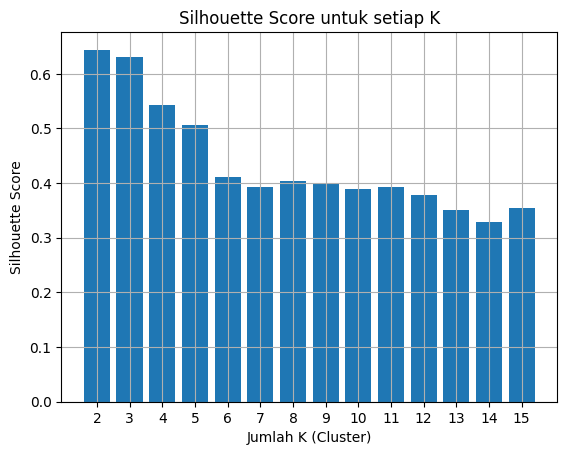

In [467]:

sscore = []
range_k = range(2,16)
for k in range_k:
    score = shilouette(data_scaled ,k)
    sscore.append(score)
plt.bar(range_k, sscore, )
plt.title(f"Silhouette Score untuk setiap K")
plt.xlabel('Jumlah K (Cluster)')
plt.ylabel('Silhouette Score')
plt.xticks(range_k)
plt.grid(True)
plt.show()

In [468]:
cluster, centroid = kmean(data_scaled, k=2)

data_scaled['cluster'] = cluster
data_scaled.sample(15)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,cluster
84,0.305556,0.416667,0.593220,0.583333,0.5,0
20,0.305556,0.583333,0.118644,0.041667,0.0,1
45,0.138889,0.416667,0.067797,0.083333,0.0,1
47,0.083333,0.500000,0.067797,0.041667,0.0,1
149,0.444444,0.416667,0.694915,0.708333,1.0,0
114,0.416667,0.333333,0.694915,0.958333,1.0,0
144,0.666667,0.541667,0.796610,1.000000,1.0,0
117,0.944444,0.750000,0.966102,0.875000,1.0,0
9,0.166667,0.458333,0.084746,0.000000,0.0,1
90,0.333333,0.250000,0.576271,0.458333,0.5,0


In [ ]:
from tkinter import *

# feature = data_scaled[data_scaled.columns]
entry_dict = {}

data_mean = feature.mean(axis=0).to_numpy
data_mean = feature.std(axis=0).to_numpy

def prediksi():
    try:
        # A. Ambil semua nilai dari entry berdasarkan kolom_fitur
        data_list = []
        for col in feature:
            val = float(entry_dict[col].get())
            data_list.append(val)
            
        # B. Jadikan Array Numpy
        data_input = np.array(data_list)

        # C. Standarisasi 
        data_scaled = (data_input - data_mean) / data_mean

        # D. Proyeksi PCA 
        data_pca = np.dot(data_scaled, vector_pca)

        # E. Hitung Jarak ke Semua Centroid (Euclidean Distance)
        jarak = np.linalg.norm(centroid - data_pca, axis=1)

        # F. Ambil yang Paling Dekat (Min)
        cluster_terpilih = np.argmin(jarak)

        # G. Tampilkan Hasil
        messagebox.showinfo("Hasil Prediksi", f"Cluster: {cluster_terpilih}")
        
    except ValueError:
        messagebox.showerror("Eror","Input Harus Angka!")

# GUI UTAMA
root = tk.Tk()
root.title("K-Means Clustering")
root.geometry("500x700") # Diperlebar sedikit karena fiturnya banyak
root.config(bg="#1e3d59")

# Header
header = Frame(root, bg="#f5f0e1")
header.pack(fill=X)
Label(header, text="Pengelompokan Bunga Iris", font=('Arial', 18, 'bold'), fg='#1e3d59', bg="#f5f0e1").pack(pady=5)

main = Frame(root, bg="#1e3d59")
main.pack(pady=10)

# Looping untuk membuat Label dan Entry secara otomatis
for col in feature:
    Label(main, text=col.replace('_', ' ').title(), font=('Arial', 10, 'bold'), fg='white', bg="#1e3d59").pack(pady=(5,0))
    ent = Entry(main, width=30)
    ent.pack()
    entry_dict[col] = ent # Simpan referensi entry ke dalam dictionary

hasil_frame = Frame(root, bg="#1e3d59")
hasil_frame.pack(pady=20)

button = Button(hasil_frame, text='PREDIKSI KLASTER', font=('Arial', 11, 'bold'), 
                bg="#00da45", fg='white', command=prediksi)
button.pack(ipadx=10, ipady=5)

hasil_prediksi = Label(hasil_frame, text='-', font=('Arial', 16, 'bold'), fg='#00da45', bg="#1e3d59")
hasil_prediksi.pack(pady=10)

root.mainloop()

In [470]:
# root = tk.Tk()

# root.configure(bg='#1E1D1F')

# # frame
# frame = tk.Frame(root)
# frame.configure(bg="#1D1E1F")
# frame.place(relx=0.5, rely=0.5, anchor='center')

# # label1
# label1 = tk.Label(frame,
#                   text='PENGELOMPOKAN BUNGA IRIS',
#                   font=('Arial', 28, 'bold'),
#                   bg='#1E1D1F',
#                   fg='#FFFFFF')

# # label2
# label2 = tk.Label(frame,
#                   text='Sepal Length',
#                   font=('Arial', 20),
#                   bg='#1E1D1F',
#                   fg='#FFFFFF')

# # label3
# label3 = tk.Label(frame,
#                   text='Sepal Width',
#                   font=('Arial', 20),
#                   bg='#1E1D1F',
#                   fg='#FFFFFF')

# # label4
# label4 = tk.Label(frame,
#                   text='Petal Length',
#                   font=('Arial', 20),
#                   bg='#1E1D1F',
#                   fg='#FFFFFF')

# # label5
# label5 = tk.Label(frame,
#                   text='Petal Width',
#                   font=('Arial', 20),
#                   bg='#1E1D1F',
#                   fg='#FFFFFF')

# # label6
# label6 = tk.Label(frame,
#                   text='Species',
#                   font=('Arial', 20),
#                   bg='#1E1D1F',
#                   fg='#FFFFFF')

# # entry1
# entry1 = tk.Entry(frame,
#                   font=('Arial', 18),
#                   bg="#3A3A3A",
#                   fg='#FFFFFF')

# # entry2
# entry2 = tk.Entry(frame,
#                   font=('Arial', 18),
#                   bg="#3A3A3A",
#                   fg='#FFFFFF')

# # entry3
# entry3 = tk.Entry(frame,
#                   font=('Arial', 18),
#                   bg="#3A3A3A",
#                   fg='#FFFFFF')

# # entry4
# entry4 = tk.Entry(frame,
#                   font=('Arial', 18),
#                   bg="#3A3A3A",
#                   fg='#FFFFFF')

# # entry5
# entry5 = tk.Entry(frame,
#                   font=('Arial', 18),
#                   bg="#3A3A3A",
#                   fg='#FFFFFF')

# # inisialisasi lokasi 
# label1.pack()
# label2.pack(pady=10)
# entry1.pack()
# label3.pack(pady=10)
# entry2.pack()
# label4.pack(pady=10)
# entry3.pack()
# label5.pack(pady=10)
# entry4.pack()
# label6.pack(pady=10)
# entry5.pack()
# root.mainloop()